# K - Nearst Neighbour - 
-                       Distance based Algorithem hai. jaha bhi distance bassed algo hoti hai waha Normaliaze kana padata hai.
- Lazy learner - traning ke time prr sust rahta hai(Time jada leta hai).
- Eager learner - testing ke time tez ho jata hai(Time kam leta hai).
- distance ke base pr lete hai.

### Type of method
1. Ecuclidian -
2. manha -
3. Minkkovski - 


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk 
import warnings

warnings.filterwarnings('ignore')


In [26]:
Titanic_df = pd.read_csv(r'D:\AI & ML\Machine_Learning_19\Dataset\Titanic-Dataset.csv')
Titanic_df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


# EDA

In [27]:
Titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
Titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
Titanic_df.drop(['PassengerId','Name','Cabin','Ticket'], axis=1, inplace=True)
Titanic_df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S


In [30]:
Titanic_df['Age'] = Titanic_df['Age'].fillna(Titanic_df['Age'].mean())
Titanic_df['Embarked'] = Titanic_df['Embarked'].fillna(Titanic_df["Embarked"].mode()[0])


In [31]:
catego_col = Titanic_df.select_dtypes(include='object').columns
catego_col

Index(['Sex', 'Embarked'], dtype='object')

In [32]:
from sklearn.preprocessing import LabelEncoder
Lab_Encoder = LabelEncoder()

for i in catego_col:
    Titanic_df[i] = Lab_Encoder.fit_transform(Titanic_df[i])

Titanic_df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2


In [34]:
Independent = Titanic_df.drop(('Survived'),axis=1)
Dependent = Titanic_df['Survived']

In [35]:
Independent

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.000000,1,0,7.2500,2
1,1,0,38.000000,1,0,71.2833,0
2,3,0,26.000000,0,0,7.9250,2
3,1,0,35.000000,1,0,53.1000,2
4,3,1,35.000000,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,1,27.000000,0,0,13.0000,2
887,1,0,19.000000,0,0,30.0000,2
888,3,0,29.699118,1,2,23.4500,2
889,1,1,26.000000,0,0,30.0000,0


In [36]:
from sklearn.preprocessing import StandardScaler # Normalize krr rahe hai.
Indep_scaled = StandardScaler().fit_transform(Independent)

In [37]:
Indep_scaled

array([[ 0.82737724,  0.73769513, -0.5924806 , ..., -0.47367361,
        -0.50244517,  0.58595414],
       [-1.56610693, -1.35557354,  0.63878901, ..., -0.47367361,
         0.78684529, -1.9423032 ],
       [ 0.82737724, -1.35557354, -0.2846632 , ..., -0.47367361,
        -0.48885426,  0.58595414],
       ...,
       [ 0.82737724, -1.35557354,  0.        , ...,  2.00893337,
        -0.17626324,  0.58595414],
       [-1.56610693,  0.73769513, -0.2846632 , ..., -0.47367361,
        -0.04438104, -1.9423032 ],
       [ 0.82737724,  0.73769513,  0.17706291, ..., -0.47367361,
        -0.49237783, -0.67817453]])

In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(Indep_scaled,Dependent,test_size=0.3 , random_state=42, stratify = Dependent) # for stoping suffling
 # stratify use for 70 and 30


# Model Building KNN

In [39]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5).fit(X_train,Y_train) # odd number hi lete hai kyuki dono jagaah same ho jayega.

In [40]:
knn_predict =  knn_model.predict(X_test)
knn_predict

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1], dtype=int64)

In [41]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,classification_report  ,f1_score

<Axes: >

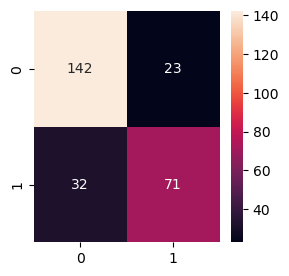

In [42]:
plt.figure(figsize=(3,3))
sns.heatmap(confusion_matrix(Y_test,knn_predict), annot=True, fmt = 'd')

In [43]:
print(f'accuracy score = ',accuracy_score(Y_test,knn_predict)*100)
print(f'Precision score = ',precision_score(Y_test,knn_predict)*100)
print(f'Recall score = ',recall_score(Y_test,knn_predict)*100)
print(f'F1_score= ',f1_score(Y_test,knn_predict)*100)

accuracy score =  79.47761194029852
Precision score =  75.53191489361703
Recall score =  68.93203883495146
F1_score=  72.08121827411168


In [44]:
print(f'classification Report :{classification_report(Y_test,knn_predict)*100}')

classification Report :              precision    recall  f1-score   support

           0       0.82      0.86      0.84       165
           1       0.76      0.69      0.72       103

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       165
           1       0.76      0.69      0.72       103

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       165
           1       0.76      0.69      0.72       103

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268